In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from scipy.signal import periodogram
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [53]:
data_2022 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2022', header=1, usecols = "A:G")
data_2022 = data_2022[data_2022["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()
data_2023 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2023', header=1, usecols = "A:G")
data_2023 = data_2023[data_2023["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()
data_2024 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2024', header=1, usecols = "A:G")
data_2024 = data_2024[data_2024["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()

data = pd.concat([data_2022, data_2023, data_2024], ignore_index=True)
data = data[["Date", "Daily Demand (Units)"]]
data["Date"] = pd.to_datetime(data["Date"])
data["Daily Demand (Units)"] = pd.to_numeric(data["Daily Demand (Units)"], errors='coerce')
df = data[['Date', 'Daily Demand (Units)']]
df.set_index('Date', inplace=True)
df.index.freq = pd.infer_freq(df.index)

monthly = df["Daily Demand (Units)"].resample("M").mean()
monthly.index = monthly.index.to_period("M").to_timestamp()

In [54]:
test_size = 6
train = monthly.iloc[:-test_size]
test = monthly.iloc[-test_size:]

In [55]:
def compute_metrics(actual, predicted, label=""):
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask      = np.isfinite(actual) & np.isfinite(predicted)
    actual, predicted = actual[mask], predicted[mask]
    residuals = actual - predicted
    return dict(
        label     = label,
        MAE       = mean_absolute_error(actual, predicted),
        RMSE      = np.sqrt(mean_squared_error(actual, predicted)),
        MAPE      = np.mean(np.abs(residuals / actual)) * 100,
        Bias      = np.mean(residuals),
        DW        = durbin_watson(residuals),
        residuals = residuals
    )

In [56]:
def make_fourier_X(t_arr, K, period=12):
    cols = [t_arr]
    for k in range(1, K+1):
        cols += [np.sin(2*np.pi*k*t_arr/period),
                 np.cos(2*np.pi*k*t_arr/period)]
    return np.column_stack(cols)


def run_moving_average(train, test, window=3):
    fitted   = train.rolling(window, min_periods=1).mean().shift(1).bfill()
    forecast = pd.Series([train.iloc[-window:].mean()] * len(test), index=test.index)
    return fitted, forecast, f"Moving Average (w={window})"


def run_hw_additive(train, test):
    m        = ExponentialSmoothing(train, trend="add", seasonal="add",
                                    seasonal_periods=12).fit(optimized=True)
    fitted   = m.fittedvalues
    forecast = pd.Series(m.forecast(len(test)).values, index=test.index)
    return fitted, forecast, "Holt-Winters Additive"


def run_hw_multiplicative(train, test):
    m        = ExponentialSmoothing(train, trend="add", seasonal="mul",
                                    seasonal_periods=12).fit(optimized=True)
    fitted   = m.fittedvalues
    forecast = pd.Series(m.forecast(len(test)).values, index=test.index)
    return fitted, forecast, "Holt-Winters Multiplicative"


def run_polynomial_regression(train, test, degree=2):
    t_tr    = np.arange(len(train)).reshape(-1, 1)
    poly    = PolynomialFeatures(degree=degree, include_bias=False)
    dummies_tr = pd.get_dummies(train.index.month, prefix="M",
                                 drop_first=True).values.astype(float)
    X_tr    = np.hstack([poly.fit_transform(t_tr), dummies_tr])
    model   = LinearRegression().fit(X_tr, train.values)
    fitted  = pd.Series(model.predict(X_tr), index=train.index)

    t_te    = np.arange(len(train), len(train)+len(test)).reshape(-1, 1)
    dummies_te = pd.get_dummies(test.index.month, prefix="M").reindex(
                    columns=[f"M_{i}" for i in range(2,13)],
                    fill_value=0).values.astype(float)
    X_te    = np.hstack([poly.transform(t_te), dummies_te])
    forecast= pd.Series(model.predict(X_te), index=test.index)
    return fitted, forecast, f"Polynomial Regression (deg={degree})"


def run_cosine_regression(train, test):
    t_tr    = np.arange(len(train), dtype=float)
    X_tr    = np.column_stack([t_tr,
                                np.sin(2*np.pi*t_tr/12),
                                np.cos(2*np.pi*t_tr/12)])
    model   = LinearRegression().fit(X_tr, train.values)
    fitted  = pd.Series(model.predict(X_tr), index=train.index)

    t_te    = np.arange(len(train), len(train)+len(test), dtype=float)
    X_te    = np.column_stack([t_te,
                                np.sin(2*np.pi*t_te/12),
                                np.cos(2*np.pi*t_te/12)])
    forecast= pd.Series(model.predict(X_te), index=test.index)
    return fitted, forecast, "Cosine Regression (K=1)"


def run_fourier_regression(train, test, K=3):
    t_tr    = np.arange(len(train), dtype=float)
    X_tr    = make_fourier_X(t_tr, K)
    model   = LinearRegression().fit(X_tr, train.values)
    fitted  = pd.Series(model.predict(X_tr), index=train.index)

    t_te    = np.arange(len(train), len(train)+len(test), dtype=float)
    X_te    = make_fourier_X(t_te, K)
    forecast= pd.Series(model.predict(X_te), index=test.index)
    return fitted, forecast, f"Fourier Regression (K={K})"

In [57]:
raw = [
    run_moving_average(train, test, window=3),
    run_hw_additive(train, test),
    run_hw_multiplicative(train, test),
    run_polynomial_regression(train, test, degree=2),
    run_cosine_regression(train, test),
    run_fourier_regression(train, test, K=3),
]

models = {}
print(f"\n{'Model':<42} {'Train MAPE':>11} {'Test MAPE':>10} {'Test RMSE':>10} {'Test MAE':>9} {'Bias':>8}")
print("─" * 95)

for fitted, forecast, name in raw:
    train_m = compute_metrics(train,  fitted,   label="train")
    test_m  = compute_metrics(test,   forecast, label="test")
    models[name] = {
        "fitted":      fitted,
        "forecast":    forecast,
        "train":       train_m,
        "test":        test_m,
    }
    print(f"{name:<42} {train_m['MAPE']:>10.2f}% {test_m['MAPE']:>9.2f}% "
          f"{test_m['RMSE']:>10.2f} {test_m['MAE']:>9.2f} {test_m['Bias']:>+8.2f}")


Model                                       Train MAPE  Test MAPE  Test RMSE  Test MAE     Bias
───────────────────────────────────────────────────────────────────────────────────────────────
Moving Average (w=3)                             8.55%      5.07%      16.03     12.47    -9.18
Holt-Winters Additive                            0.91%      1.68%       4.78      4.24    -2.64
Holt-Winters Multiplicative                      0.92%      1.95%       5.96      4.88    +1.04
Polynomial Regression (deg=2)                    0.95%      1.76%       5.21      4.46    -3.79
Cosine Regression (K=1)                          3.67%      4.26%      15.28     10.91    +3.75
Fourier Regression (K=3)                         2.75%      1.79%       7.62      4.74    +3.26


In [58]:
def rolling_cv(series, model_fn, n_splits=5, horizon=3):
    """
    Expanding-window CV.
    Each fold trains on progressively more data
    and tests on the next `horizon` months.
    """
    min_train = max(14, len(series) - n_splits * horizon)
    results   = []

    for fold in range(n_splits):
        end_train = min_train + fold * horizon
        if end_train + horizon > len(series):
            break
        cv_train = series.iloc[:end_train]
        cv_test  = series.iloc[end_train: end_train + horizon]
        try:
            _, fc, _ = model_fn(cv_train, cv_test)
            m        = compute_metrics(cv_test, fc)
            results.append({"fold": fold+1, "MAPE": m["MAPE"], "RMSE": m["RMSE"]})
        except Exception:
            pass

    if not results:
        return {"CV_MAPE_mean": np.nan, "CV_MAPE_std": np.nan}

    mapes = [r["MAPE"] for r in results]
    return {"CV_MAPE_mean": np.mean(mapes), "CV_MAPE_std": np.std(mapes)}

model_fns = {
    "Moving Average (w=3)":          lambda tr, te: run_moving_average(tr, te, 3),
    "Holt-Winters Additive":          run_hw_additive,
    "Holt-Winters Multiplicative":    run_hw_multiplicative,
    "Polynomial Regression (deg=2)":  run_polynomial_regression,
    "Cosine Regression (K=1)":        run_cosine_regression,
    "Fourier Regression (K=3)":       lambda tr, te: run_fourier_regression(tr, te, 3),
}

print(f"\n── Rolling CV Results (5 folds, horizon=3 months) ──────────────────")
print(f"{'Model':<42} {'CV MAPE Mean':>14} {'CV MAPE Std':>13}")
print("─" * 72)
for name, fn in model_fns.items():
    cv = rolling_cv(monthly, fn)
    models[name]["cv"] = cv
    print(f"{name:<42} {cv['CV_MAPE_mean']:>13.2f}% {cv['CV_MAPE_std']:>12.2f}%")


── Rolling CV Results (5 folds, horizon=3 months) ──────────────────
Model                                        CV MAPE Mean   CV MAPE Std
────────────────────────────────────────────────────────────────────────
Moving Average (w=3)                                8.22%         5.28%
Holt-Winters Additive                               2.48%         0.42%
Holt-Winters Multiplicative                         2.07%         1.42%
Polynomial Regression (deg=2)                       1.90%         1.02%
Cosine Regression (K=1)                             5.01%         2.48%
Fourier Regression (K=3)                            2.98%         1.22%


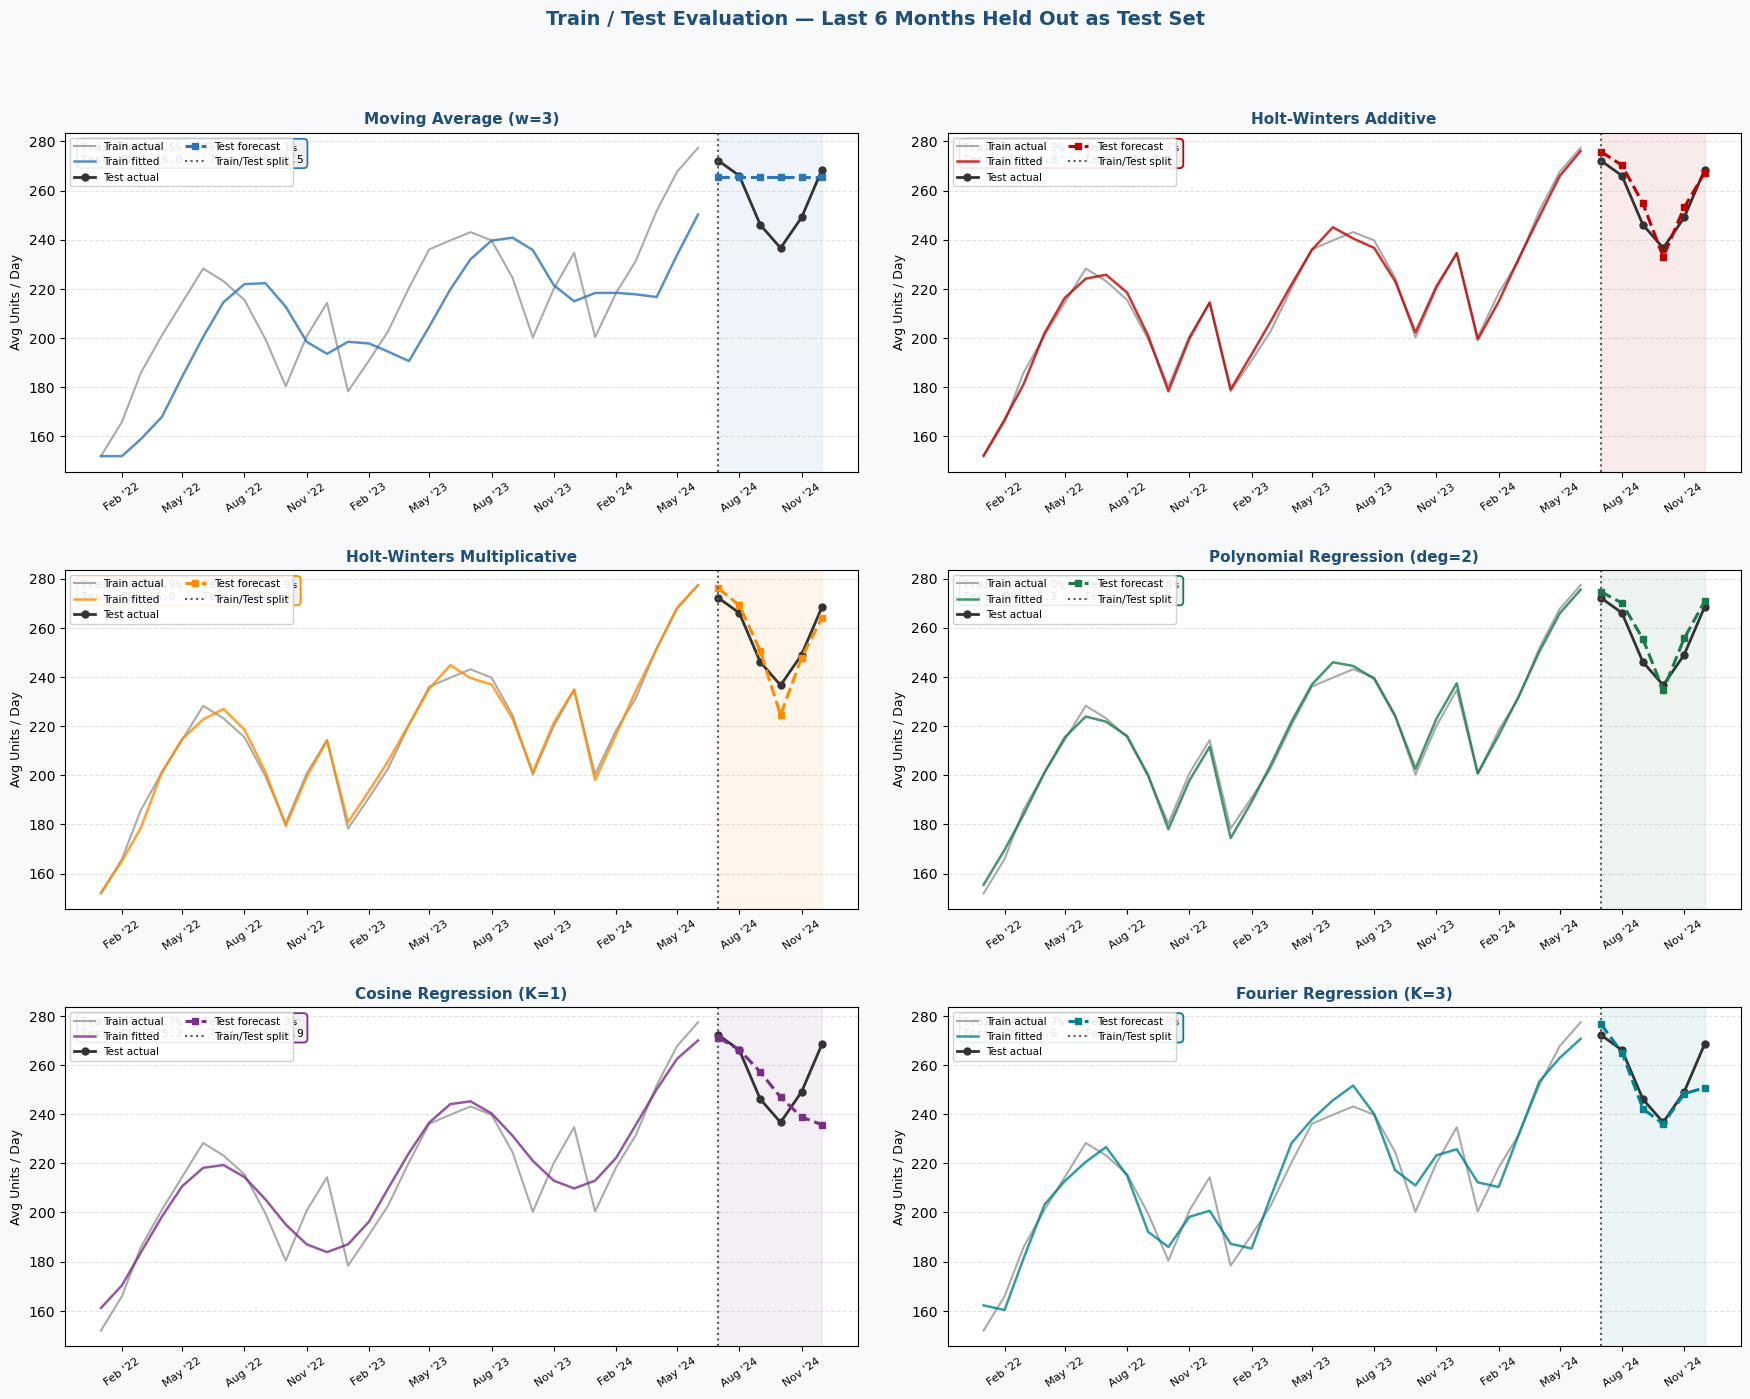

In [59]:
palette = ["#2E75B6","#C00000","#FF8C00","#1A7A4A","#7B2D8B","#00838F"]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("Train / Test Evaluation — Last 6 Months Held Out as Test Set",
             fontsize=14, fontweight="bold", color="#1F4E79", y=1.01)

for ax, (name, res), color in zip(axes.flat, models.items(), palette):
    ax.set_facecolor("#FFFFFF")

    # Train actual + fitted
    ax.plot(train.index, train.values, color="#AAAAAA", lw=1.5, label="Train actual")
    ax.plot(res["fitted"].index, res["fitted"].values,
            color=color, lw=1.8, alpha=0.8, label="Train fitted")

    # Test actual vs forecast
    ax.plot(test.index, test.values,
            color="#333333", lw=2.0, marker="o", markersize=5, label="Test actual")
    ax.plot(res["forecast"].index, res["forecast"].values,
            color=color, lw=2.2, linestyle="--", marker="s",
            markersize=5, label="Test forecast")

    # Shade test region
    ax.axvspan(test.index[0], test.index[-1], alpha=0.08, color=color)
    ax.axvline(test.index[0], color="#595959", lw=1.5, linestyle=":",
               label="Train/Test split")

    # Metrics box
    tr_m, te_m = res["train"], res["test"]
    ax.text(0.02, 0.97,
            f"Train MAPE={tr_m['MAPE']:.1f}%   Test MAPE={te_m['MAPE']:.1f}%\n"
            f"Test  RMSE={te_m['RMSE']:.1f}    Test  MAE={te_m['MAE']:.1f}",
            transform=ax.transAxes, fontsize=8, va="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#F0F0F0",
                      edgecolor=color, lw=1.3))

    ax.set_title(name, fontsize=11, fontweight="bold", color="#1F4E79", pad=6)
    ax.set_ylabel("Avg Units / Day", fontsize=9)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b '%y"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.legend(fontsize=7.5, framealpha=0.9, ncol=2)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout(pad=2.5)
plt.savefig("images/train_test_evaluation.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

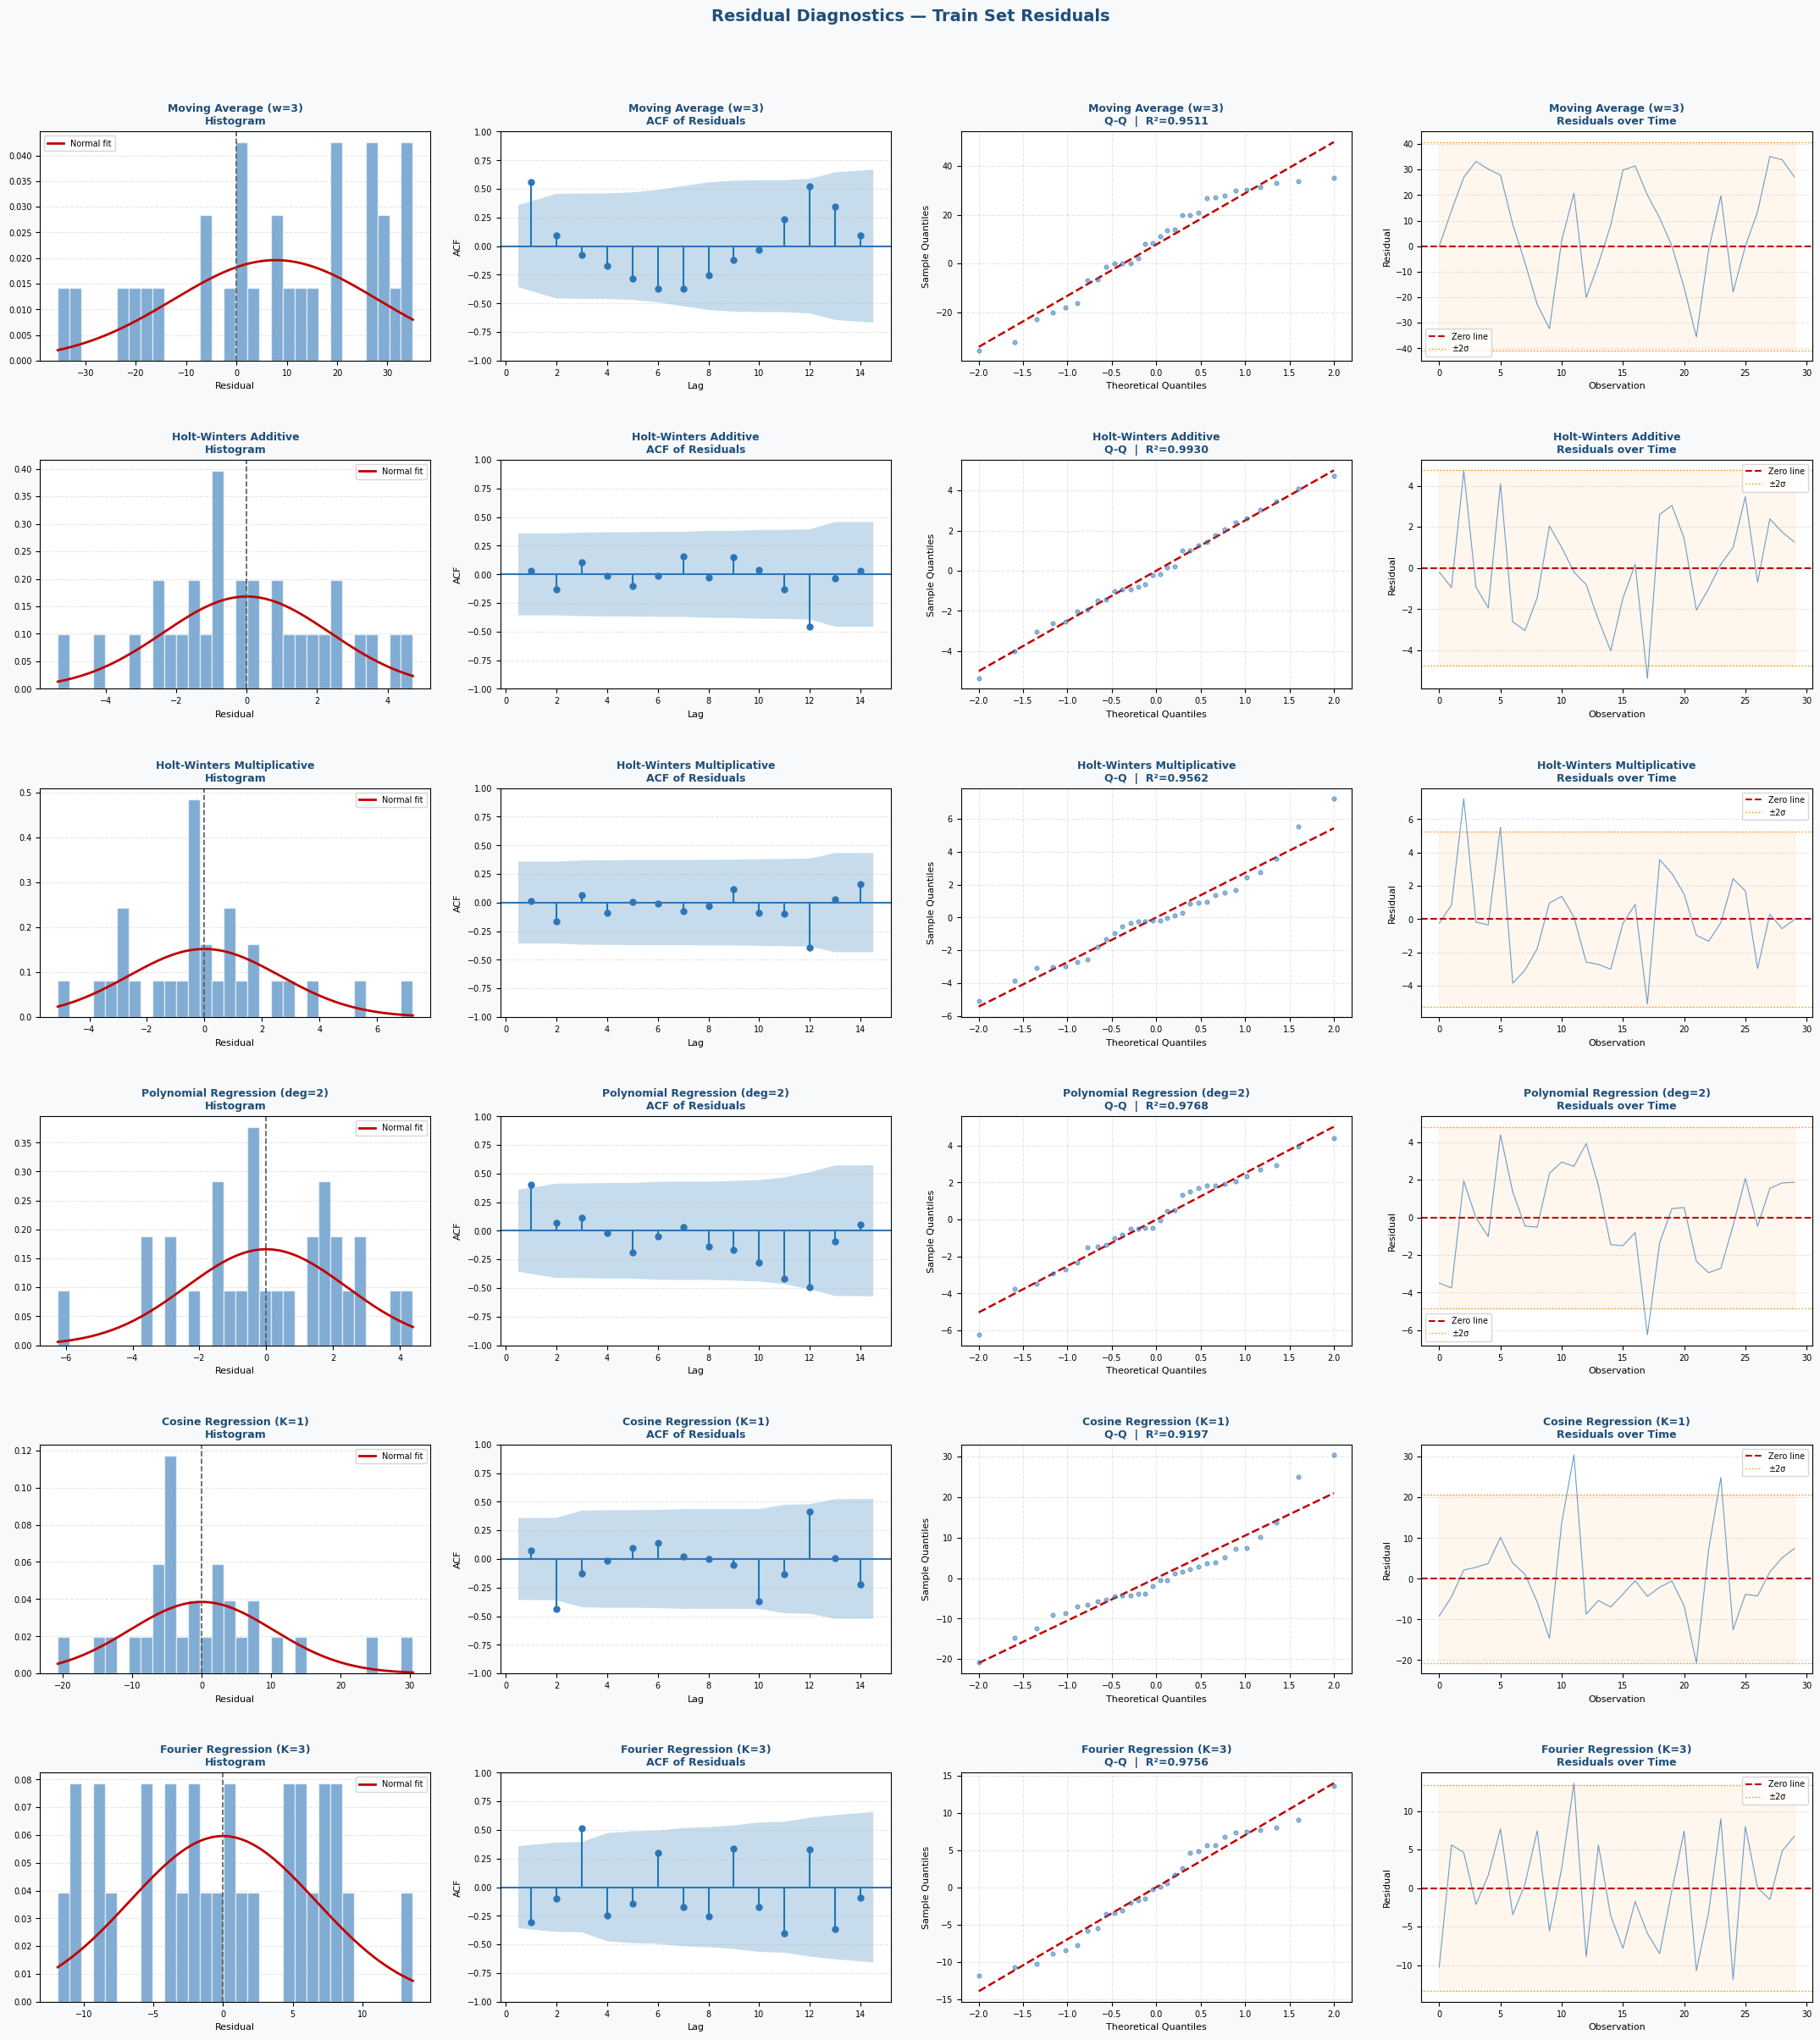

In [60]:
def plot_residual_diagnostics(residuals, model_name, ax_row):
    res       = np.array(residuals, dtype=float)
    res       = res[np.isfinite(res)]
    mu, sigma = res.mean(), res.std()
    color     = "#2E75B6"

    ax = ax_row[0]
    ax.set_facecolor("#FFFFFF")
    ax.hist(res, bins=30, color=color, alpha=0.6, edgecolor="white", density=True)
    xr = np.linspace(res.min(), res.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, mu, sigma), color="#C00000", lw=2, label="Normal fit")
    ax.axvline(0, color="#595959", lw=1.2, linestyle="--")
    ax.set_title(f"{model_name}\nHistogram", fontsize=9, fontweight="bold", color="#1F4E79")
    ax.set_xlabel("Residual", fontsize=8); ax.legend(fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.3); ax.tick_params(labelsize=7)

    ax = ax_row[1]
    ax.set_facecolor("#FFFFFF")
    max_lags = min(20, len(res)//2 - 1)
    plot_acf(res, lags=max_lags, ax=ax, color=color, alpha=0.05, zero=False)
    ax.set_title(f"{model_name}\nACF of Residuals", fontsize=9, fontweight="bold", color="#1F4E79")
    ax.set_xlabel("Lag", fontsize=8); ax.set_ylabel("ACF", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3); ax.tick_params(labelsize=7)

    ax = ax_row[2]
    ax.set_facecolor("#FFFFFF")
    (osm, osr), (slope, intercept, r) = stats.probplot(res, dist="norm")
    ax.scatter(osm, osr, color=color, alpha=0.5, s=12, zorder=3)
    ax.plot(osm, slope*np.array(osm)+intercept, color="#C00000", lw=1.8, linestyle="--")
    ax.set_title(f"{model_name}\nQ-Q  |  R²={r**2:.4f}", fontsize=9,
                 fontweight="bold", color="#1F4E79")
    ax.set_xlabel("Theoretical Quantiles", fontsize=8)
    ax.set_ylabel("Sample Quantiles",      fontsize=8)
    ax.grid(linestyle="--", alpha=0.3); ax.tick_params(labelsize=7)

    ax = ax_row[3]
    ax.set_facecolor("#FFFFFF")
    ax.plot(res, color=color, lw=0.8, alpha=0.7)
    ax.axhline(0,        color="#C00000",  lw=1.5, linestyle="--", label="Zero line")
    ax.axhline(+2*sigma, color="#FF8C00",  lw=1.0, linestyle=":",  label="±2σ")
    ax.axhline(-2*sigma, color="#FF8C00",  lw=1.0, linestyle=":")
    ax.fill_between(range(len(res)), -2*sigma, 2*sigma, alpha=0.07, color="#FF8C00")
    ax.set_title(f"{model_name}\nResiduals over Time", fontsize=9,
                 fontweight="bold", color="#1F4E79")
    ax.set_xlabel("Observation", fontsize=8); ax.set_ylabel("Residual", fontsize=8)
    ax.legend(fontsize=7); ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(labelsize=7)

n_models = len(models)
fig2, axes2 = plt.subplots(n_models, 4, figsize=(22, n_models * 4))
fig2.patch.set_facecolor("#F8F9FA")
fig2.suptitle("Residual Diagnostics — Train Set Residuals",
              fontsize=14, fontweight="bold", color="#1F4E79", y=1.01)

for i, (name, res) in enumerate(models.items()):
    plot_residual_diagnostics(res["train"]["residuals"], name, axes2[i])

plt.tight_layout(pad=2.5, h_pad=3.5, w_pad=2.0)
plt.savefig("images/residual_diagnostics.png", dpi=150,
            bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()

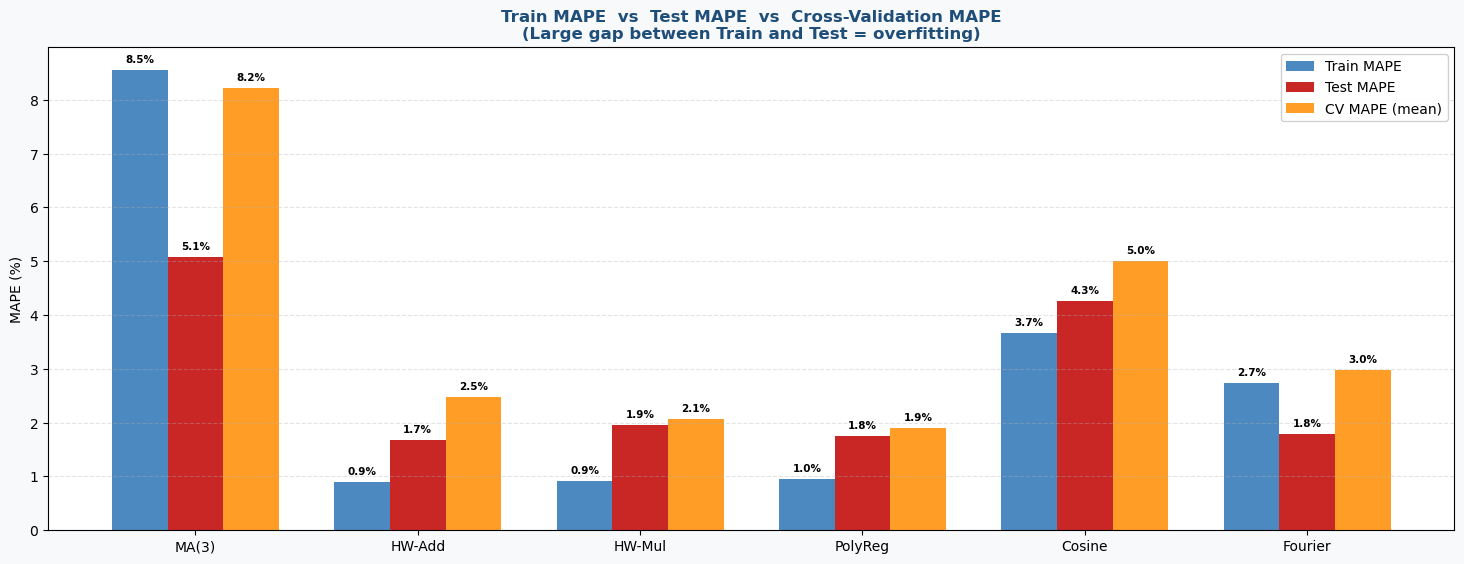

Saved: model_comparison.png


In [61]:
short  = ["MA(3)","HW-Add","HW-Mul","PolyReg","Cosine","Fourier"]
x      = np.arange(len(short))
width  = 0.25

fig3, ax = plt.subplots(figsize=(15, 6))
fig3.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#FFFFFF")

train_mapes = [models[m]["train"]["MAPE"] for m in models]
test_mapes  = [models[m]["test"]["MAPE"]  for m in models]
cv_mapes    = [models[m]["cv"]["CV_MAPE_mean"] for m in models]

b1 = ax.bar(x - width, train_mapes, width, label="Train MAPE",  color="#2E75B6", alpha=0.85)
b2 = ax.bar(x,         test_mapes,  width, label="Test MAPE",   color="#C00000", alpha=0.85)
b3 = ax.bar(x + width, cv_mapes,    width, label="CV MAPE (mean)", color="#FF8C00", alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if np.isfinite(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f"{h:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_title("Train MAPE  vs  Test MAPE  vs  Cross-Validation MAPE\n"
             "(Large gap between Train and Test = overfitting)",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.set_ylabel("MAPE (%)", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout(pad=2)
plt.savefig("images/model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print("Saved: model_comparison.png")

### From the results, the best model for the data is Holt-Winters Additive